<h1 style="text-align:center; color:black;"><b>Automatic Grouping of Dry Beans Using Unsupervised Learning</b></h1>

<h3 style="text-align:center; color:black;">Author: Nur Bozdemir</h3>

* **Scenario:** A large volume of dry beans is imported regularly. As a data scientist, I propose an automated solution that uses unsupervised machine learning to cluster the incoming beans based on their physical features

* **Problem and Approach:** My goal is to group beans based only on physical features (like area, perimeter, length) using unsupervised learning. The project does not use any labels.

* **Dataset and Suitability:** I use the Dry Bean Dataset with 13,611 samples and 16 numerical features. It is a good fit for PCA and distance-based clustering algorithms.

* **Methods:** I use three clustering algorithms: K-Means, DBSCAN, and Hierarchical Clustering (HAC).

* **Expected Value:** The project aims to make sorting beans faster, more accurate, and scalable. It helps automate the company’s supply chain process.

# Imports and Settings

In [31]:
import pandas as pd
# make pandas display ALL columns of a dataframe
pd.options.display.max_columns = None
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.decomposition import PCA
import numpy as np
from sklearn.cluster import KMeans
import pandas as pd
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
from mpl_toolkits.mplot3d import Axes3D
import itertools
from sklearn.neighbors import NearestNeighbors
import plotly.express as px
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import pdist
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.cm as cm
from scipy.cluster.hierarchy import dendrogram
from matplotlib.lines import Line2D
from sklearn.metrics import silhouette_score, davies_bouldin_score

# The Data

* **Source:** The dataset was downloaded from the UCI Machine Learning Repository:  
https://archive.ics.uci.edu/dataset/602/dry+bean+dataset

* **Authors:** Assoc. Prof. Dr. Murat Köklü and Assoc. Prof. Dr. İlker Ali Özkan, Selçuk University, Turkey.

* **License:** The dataset is released under the Creative Commons Attribution 4.0 International (CC BY 4.0) license.

* **License Permissions:** It allows sharing and adaptation for any purpose, including commercial use, with appropriate credit.

* **Purpose of Collection:** The dataset was originally collected to classify seven types of dry beans using physical and shape-related features extracted from images.

* **Portfolio Suitability:** The dataset meets the portfolio selection criteria. It is real-world data, not used in the course materials, and freely available under a permissive license.

## The Raw Data

In [32]:
# Load the dataset
raw_data = pd.read_excel("Dry_Bean_Dataset.xlsx")

# Show the first 3 rows
raw_data.head(3)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER





| **Feature Name**     | **Type**     | **Explanation**                                                                 |
|----------------------|--------------|---------------------------------------------------------------------------------|
| Area                 | $\mathbb{R}$     | Represents the surface area of the bean.                                       |
| Perimeter            |  $\mathbb{R}$    | The total length around the bean's edge.                                       |
| MajorAxisLength      |  $\mathbb{R}$  | The longest diameter across the bean's shape.                                  |
| MinorAxisLength      |  $\mathbb{R}$    | The shortest diameter across the bean's shape.                                 |
| AspectRation         |  $\mathbb{R}$  | Ratio of the major axis to the minor axis, indicating shape elongation.        |
| Eccentricity         |  $\mathbb{R}$   | Describes how much the bean shape deviates from being circular.                |
| ConvexArea           |  $\mathbb{R}$  | The area of the convex hull, capturing the smallest convex boundary.           |
| EquivDiameter        |  $\mathbb{R}$  | The diameter of a circle with the same area as the bean.                       |
| Extent               |  $\mathbb{R}$    | Ratio of the bean’s area to its bounding box area, showing space utilization.  |
| Solidity             |  $\mathbb{R}$    | Proportion of the bean's area to its convex area, indicating compactness.      |
| Roundness            |  $\mathbb{R}$   | Measures how circular the bean is.                                             |
| Compactness          |  $\mathbb{R}$  | Describes how dense or compact the bean shape is.                              |
| ShapeFactor1         |  $\mathbb{R}$    | Additional geometric property describing the bean's shape.                     |
| ShapeFactor2         |  $\mathbb{R}$    | Additional geometric property describing the bean's shape.                     |
| ShapeFactor3         |  $\mathbb{R}$    | Additional geometric property describing the bean's shape.                     |
| ShapeFactor4         |  $\mathbb{R}$    | Additional geometric property describing the bean's shape.                     |
| Class                | Categorical  | Type of bean (*SEKER*, *DERMASON*, *SIRA*, *CALI*, *HOROZ*, *BARBUNYA*, *BOMBAY*) |

* The dataset used in this project is called the Dry Bean Dataset.

* It includes 13,611 samples of individual dry beans.

* Each sample is described by 16 numerical features, such as: Area,Perimeter,Major and Minor Axis Length, Aspect Ratio, Compactness, and more

* These features represent physical properties of the beans.

* The dataset also has one non-numerical column called Class, which shows the bean type.
This column is not used in the analysis because the project will be applying totally unsupervised learning.


* The dataset includes only numerical features, which are ideal for distance-based clustering algorithms like K-Means, DBSCAN, and HAC.

* It contains 16 physical features such as area, compactness, and shape measurements, which directly match the goal of sorting beans based on physical characteristics.
* With 13,611 samples, the dataset gives a good opportunity to see how clustering algorithms behave with a large amount of data

# Initial Data Analysis

In [33]:
raw_data.shape



(13611, 17)

The dataset contains **13,611 rows** and **17 columns**.

In [34]:
raw_data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

Out of these 17 columns:
* **16 are numerical features**, which describe the physical characteristics of the beans.
* **1 column (`Class`) is a label**, which indicates the bean type. It will not be used during the clustering process.


In [35]:
raw_data.describe()


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


 **Feature Scaling:**  
  * Features like `Area`, `ConvexArea`, and `Perimeter` have much larger numerical ranges than others such as `Solidity` or `ShapeFactor` features.  
  * To prevent large-scale features from dominating clustering results, it is important to apply feature scaling during preprocessing.

**Potential Outliers:**  
  * Features with high standard deviation, such as `Area`, `Perimeter`, and `ConvexArea`, may indicate the presence of outliers.  
  * To investigate this further, visual tools like histograms and boxplots can be used to detect and interpret these extreme values.



In [36]:
raw_data.isnull().sum()
#There are no missing values in the dataset 

Area               0
Perimeter          0
MajorAxisLength    0
MinorAxisLength    0
AspectRation       0
Eccentricity       0
ConvexArea         0
EquivDiameter      0
Extent             0
Solidity           0
roundness          0
Compactness        0
ShapeFactor1       0
ShapeFactor2       0
ShapeFactor3       0
ShapeFactor4       0
Class              0
dtype: int64

In [37]:
# To check if 0 is used instead of NaN (missing) value ın the dataset.
(raw_data == 0).any()


Area               False
Perimeter          False
MajorAxisLength    False
MinorAxisLength    False
AspectRation       False
Eccentricity       False
ConvexArea         False
EquivDiameter      False
Extent             False
Solidity           False
roundness          False
Compactness        False
ShapeFactor1       False
ShapeFactor2       False
ShapeFactor3       False
ShapeFactor4       False
Class              False
dtype: bool

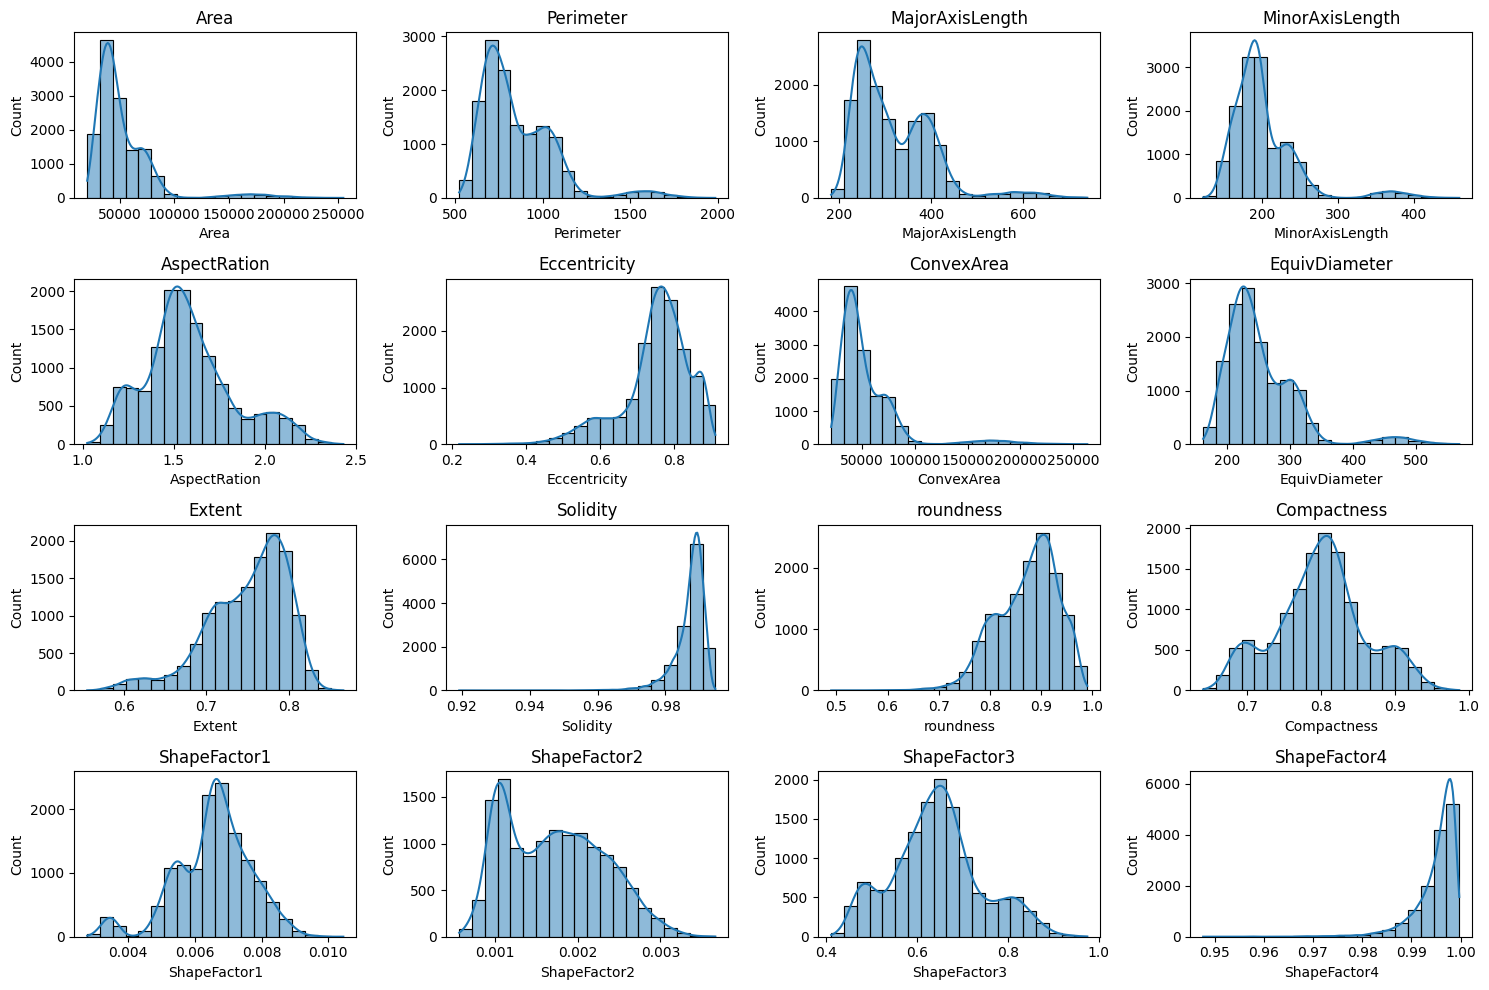

In [38]:

# Plotting histograms for all numerical columns 
plt.figure(figsize=(15, 10))

for i, column in enumerate(raw_data.select_dtypes(include=['float64', 'int64']).columns):
    plt.subplot(4, 4, i+1)  # Adjust the grid (4 rows, 4 columns for the plot)
    sns.histplot(raw_data[column], kde=True, bins=20)
    plt.title(column)  # Set the title as column name

plt.tight_layout()
plt.show()


**Skewed Distributions**

Some features show strong skewness:

- **Right-skewed:** `Area`, `Perimeter`, `ConvexArea`, `EquivDiameter`, `MajorAxisLength`, `MinorAxisLength`
- **Left-skewed:** `Solidity`, `ShapeFactor4`

These distributions suggest the presence of potential outliers, which may affect clustering results and should be addressed during preprocessing.


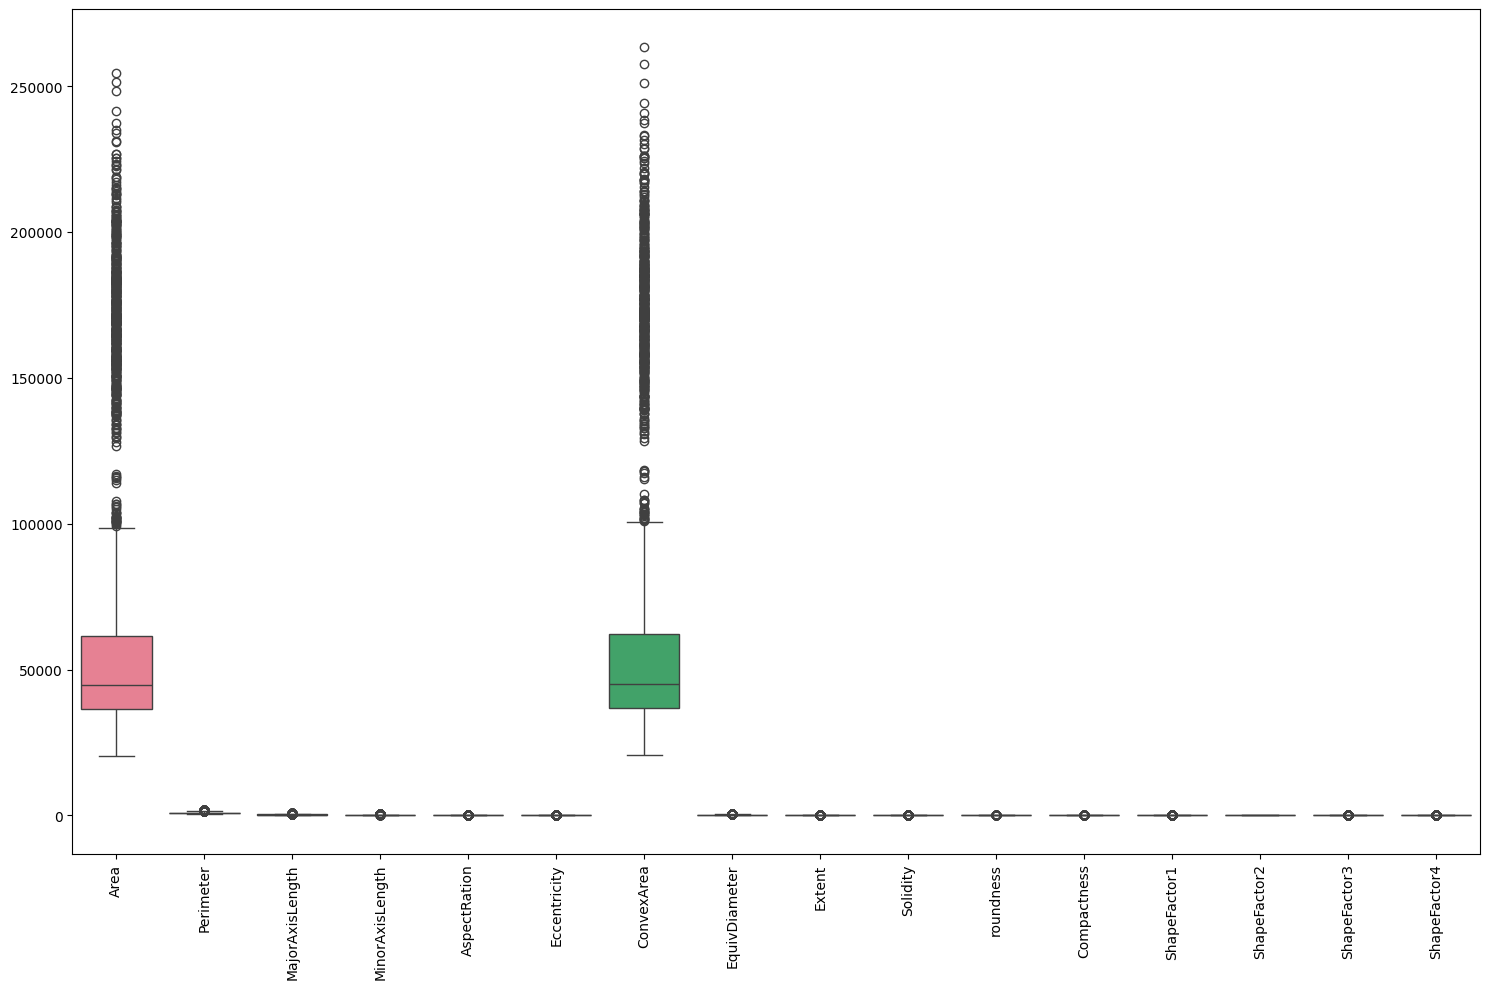

In [39]:

# Plotting boxplots for all numerical columns in raw_data
plt.figure(figsize=(15, 10))
sns.boxplot(data=raw_data)  
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.tight_layout()
plt.show()


* The boxplot and histogram above visualize the distribution of various numerical features in the dataset. 
* `Area` and `ConvexArea` show significant outliers with much higher values compared to the rest of the data, indicating a large spread and potential anomalies that may need to be addressed during data preprocessing.

#  Preprocessing



**Handling Missing Values**


* As shown in Initial Data Analysis, the dataset contains no missing values (`raw_data.isnull().sum()` was all zeros).  
* Therefore, no imputation or removal of instances was necessary in the preprocessing step.



**Dropping Label**

* I will not use any labels in the analysis.

* I will evaluate the clustering results using internal metrics such as silhouette score, which do not require label information.
 Therefore, I remove the Class (label) column from the dataset

In [40]:
raw_data_without_label = raw_data.drop(columns=["Class"])


**Outlier Detection and Removal Using IQR Method**

- The **IQR (Interquartile Range)** method is used to detect outliers.
- **Outliers** are values outside the lower and upper bounds, calculated using **Q1** (25th percentile) and **Q3** (75th percentile).
- These outliers will be removed from the numerical columns.
- This ensures that clustering algorithms are not influenced by extreme values.


In [41]:
# Calculate Q1 (25th percentile) and Q3 (75th percentile) for each feature
Q1 = raw_data_without_label.quantile(0.25)
Q3 = raw_data_without_label.quantile(0.75)
IQR = Q3 - Q1

# Define the lower and upper bounds for each feature
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
raw_data_no_outliers = raw_data_without_label[~((raw_data_without_label < lower_bound) | (raw_data_without_label > upper_bound)).any(axis=1)]

print("Raw dataset size:", raw_data.shape)
print("Size after removing outliers and dropping 'class' column:", raw_data_no_outliers.shape)


Raw dataset size: (13611, 17)
Size after removing outliers and dropping 'class' column: (10594, 16)


**Feature Scaling**

●To ensure that all features are on the same scale, we will apply **Standardization (Z-score normalization)**. This method transforms each feature so that it has a mean of 0 and a standard deviation of 1. 

●This is important because clustering algorithms are sensitive to the scale of the features, and scaling ensures that no feature dominates the clustering process.







  


In [42]:

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply the scaler to all numerical columns
scaled_data = scaler.fit_transform(raw_data_no_outliers)

# Convert the scaled data back to a DataFrame
scaled_data = pd.DataFrame(scaled_data, columns=raw_data_no_outliers.columns)

# Assign the final preprocessed data to 'data'
data = scaled_data
#Show the first few rows of the final preprocessed data
data.head()



,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
0,-0.956091,-1.013339,-1.188726,-0.615767,-1.311938,-1.606640,-0.952243,-1.008622,0.225738,-0.234421,0.833057,1.465513,0.525261,1.699878,1.508871,1.226042
1,-0.953734,-1.008638,-1.076162,-0.764712,-0.940371,-0.944364,-0.954442,-1.005636,-0.250682,0.557648,0.814761,0.951789,0.747085,1.254047,0.953859,-0.360709
2,-0.945297,-1.108799,-1.280504,-0.428483,-1.667731,-2.416528,-0.951816,-0.994964,0.500673,1.562774,1.789882,1.966782,0.296522,2.142156,2.066239,1.388639
3,-0.944553,-0.975329,-1.298301,-0.394620,-1.731879,-2.586974,-0.938258,-0.994023,0.522809,-0.662599,0.616629,2.060726,0.257428,2.229504,2.172435,1.375323
4,-0.943684,-1.015344,-1.265654,-0.445030,-1.625425,-2.308738,-0.940457,-0.992926,0.759970,-0.133286,0.967202,1.899327,0.320847,2.076934,1.990326,1.130921


- The table shows the first few rows of the preprocessed dataset (`data`).
- All features have been standardized using z-score normalization
- This transformation ensures that no feature dominates the clustering due to scale differences.


# Exploratory Data Analysis

## EDA Highlight 1

**Statistical Summary (`data.describe()`)**  
The table below displays key statistical metrics for each feature after outlier removal and scaling.



In [ ]:
# Get a statistical summary of the dataset

data.describe()


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,1.059400e+04,1.059400e+04,1.059400e+04,1.059400e+04,1.059400e+04,1.059400e+04,1.059400e+04,1.059400e+04,1.059400e+04,1.059400e+04,1.059400e+04,1.059400e+04,1.059400e+04,10594.000000,1.059400e+04,1.059400e+04
mean,4.292499e-17,-3.648624e-16,8.584998e-16,-1.931625e-16,5.687561e-16,-2.038937e-16,-2.790124e-16,-8.584998e-17,-4.359569e-16,2.698909e-14,-2.253562e-15,-4.507124e-16,5.580249e-16,0.000000,7.511873e-17,5.580249e-15
std,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047e+00,1.000047,1.000047e+00,1.000047e+00
min,-1.651940e+00,-1.875116e+00,-1.926816e+00,-1.959794e+00,-1.751015e+00,-2.639546e+00,-1.646060e+00,-1.986426e+00,-3.087431e+00,-3.029417e+00,-3.478012e+00,-2.387427e+00,-2.228775e+00,-1.860285,-2.253892e+00,-3.240115e+00
25%,-7.326716e-01,-7.660962e-01,-8.081871e-01,-7.135388e-01,-6.410652e-01,-5.079447e-01,-7.326357e-01,-7.331632e-01,-7.330635e-01,-5.363420e-01,-6.376829e-01,-5.929623e-01,-6.129569e-01,-0.868569,-6.162242e-01,-5.250275e-01
50%,-2.621348e-01,-2.385006e-01,-2.580382e-01,-1.388501e-01,-1.442872e-01,7.863450e-02,-2.646563e-01,-1.957611e-01,1.375169e-01,1.746229e-01,1.816343e-01,5.923874e-02,-1.067327e-04,0.016027,2.858064e-02,2.724516e-01
75%,5.213229e-01,7.146127e-01,8.216184e-01,4.787922e-01,4.998563e-01,6.582588e-01,5.201999e-01,6.024257e-01,8.068456e-01,7.040521e-01,7.281658e-01,6.135140e-01,6.702841e-01,0.785876,5.973526e-01,7.610508e-01
max,3.177498e+00,3.031688e+00,2.875929e+00,2.917795e+00,2.759655e+00,1.836351e+00,3.190379e+00,2.783340e+00,2.606310e+00,2.175965e+00,1.936497e+00,2.084913e+00,2.674912e+00,3.104669,2.199865e+00,1.462904e+00


- The table shows that after standardization, all features have a mean close to 0 and a standard deviation close to 1.
- Most values lie between -3 and +3, as expected from z-score normalization  
- This confirms that scaling was applied successfully.
- 10594 samples remained (It was 13611 before) after outlier removal and dropping the `Class` column.  
- No missing values are present, as all features have the same count.

## EDA Highlight 2

**Boxplots – Verifying Outlier Removal**

* Boxplots help us visually confirm that outliers have been successfully removed from the dataset.  
* After applying the IQR-based filtering and standardization, most features display compact distributions with minimal extreme values, supporting the effectiveness of our preprocessing pipeline.


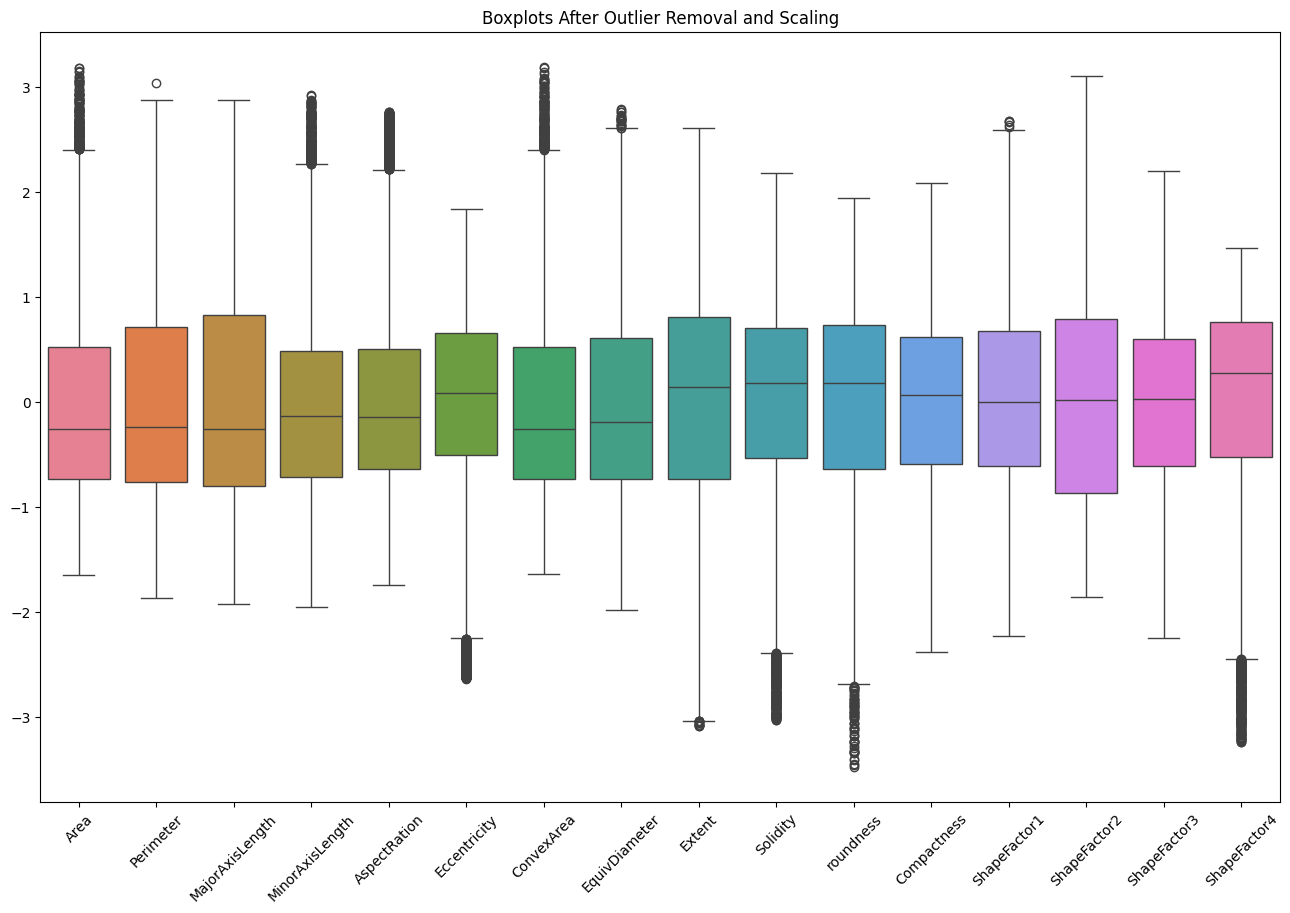

In [44]:
plt.figure(figsize=(16, 10))
sns.boxplot(data=data)
plt.xticks(rotation=45)
plt.title('Boxplots After Outlier Removal and Scaling')
plt.show()


## EDA Highlight 3

**Correlation Heatmap**


To investigate the relationships between features, we compute Pearson correlation coefficients and visualize them using a heatmap.  
This analysis helps uncover **strong linear associations**, highlights potential **feature redundancy**, and provides insights that may influence clustering performance.



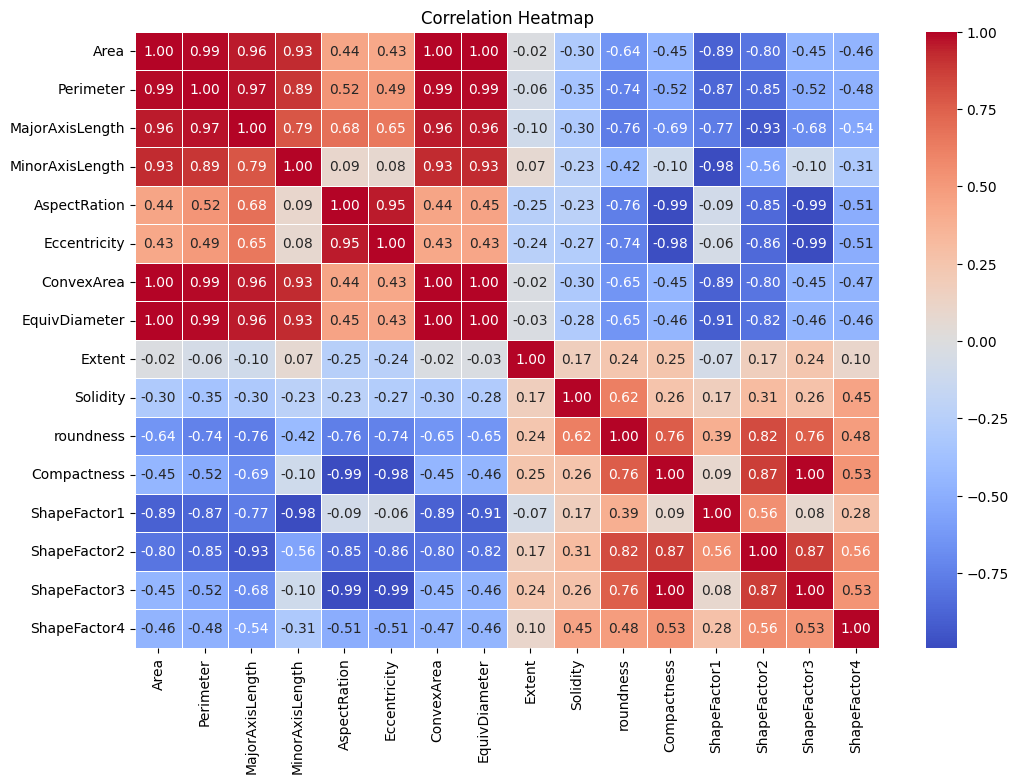

In [45]:
# Calculate the correlation matrix
correlation_matrix = data.corr()

# Plotting the heatmap of the correlation matrix
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()


* The correlation heatmap reveals strong positive relationships among several shape-related features (e.g., `Area`, `Perimeter`, `ConvexArea`, `EquivDiameter`), indicating potential redundancy.  
* Strong negative correlations, such as between `AspectRation` and `Compactness`, suggest that some features may capture opposing aspects of bean shape.  
* These findings highlight the need for dimensionality reduction before clustering.


# Dimensionality Reduction

In [46]:
# PCA model for explained variance analysis (no dimensionality reduction yet)
pca_full = PCA()
pca_full.fit(data)

# Explained variance ratios (per component)
explained_variance = pca_full.explained_variance_ratio_

# Print explained variance ratios
np.round(explained_variance, 4) 



array([6.135e-01, 2.123e-01, 7.040e-02, 5.470e-02, 3.520e-02, 7.000e-03,
       3.800e-03, 2.600e-03, 4.000e-04, 0.000e+00, 0.000e+00, 0.000e+00,
       0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00])



The first three principal components explain the majority of the variance in the dataset:

- PC1 accounts for 61.35%

- PC2 adds 21.23%, reaching a cumulative 82.58%

- PC3 contributes an additional 7.04%, bringing the total to approximately **89.62%**
Although adding PC4 and PC5 increases the explained variance to almost 98%, **I decided to use only the first 3 components**, which already capture **89.62%** of the total variance.

This is still a high amount of information, and using fewer dimensions helps reduce computational complexity and clustering time.
A lower-dimensional space is often easier to visualize and may lead to more efficient clustering, especially with large datasets.


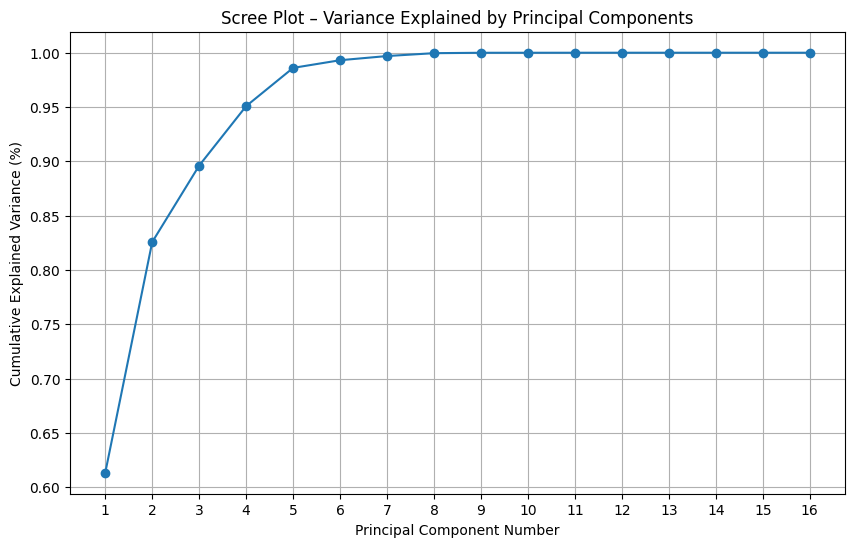

In [47]:
# Cumulative explained variance
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-')
plt.title('Scree Plot – Variance Explained by Principal Components')
plt.xlabel('Principal Component Number')
plt.ylabel('Cumulative Explained Variance (%)')
plt.grid(True)
plt.xticks(range(1, len(cumulative_variance) + 1))
plt.show()

* The scree plot shows that 3–5 components explain most of the variance. In this project, 3 components were chosen to reduce complexity while still keeping 89.6% of the total variance.

In [48]:
# Apply PCA with selected number of components (we selected 3)
pca_3d=PCA(n_components=3)
data_pca = pca_3d.fit_transform(data.copy())

#  convert to DataFrame
data_pca = pd.DataFrame(data_pca, columns=[f'PC{i+1}' for i in range(3)])

# Preview the result
data_pca.head()


,PC1,PC2,PC3
0,-4.166690,-1.133989,-0.817074
1,-3.336120,-0.036796,-0.478951
2,-5.330875,-2.367195,0.593372
3,-4.798638,-2.307700,-1.476590
4,-4.731895,-2.088031,-0.832836


**PCA Transformation Applied**

* PCA was successfully applied to reduce dimensionality from 16 to 3 features, retaining over **89.62%** of the original variance.  
* This transformation prepares the dataset (`data_pca`) for effective and efficient clustering in the next step.


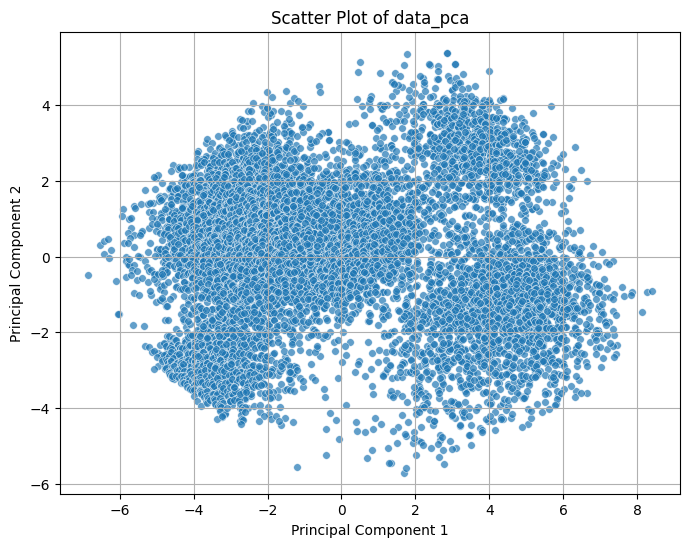

In [49]:
# Scatter plot of the first two components (PC1 and PC2) of the PCA-transformed dataset (data_pca)
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PC1', y='PC2', data=data_pca, s=30, alpha=0.7)
plt.title('Scatter Plot of data_pca')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()


- The plot shows PC1 and PC2, the first two components of the data_pca.

- PCA reduced 16 features to 3 components, keeping 89.62% of the total variance.

- The plot shows structure and density changes, suggesting possible clustering patterns.

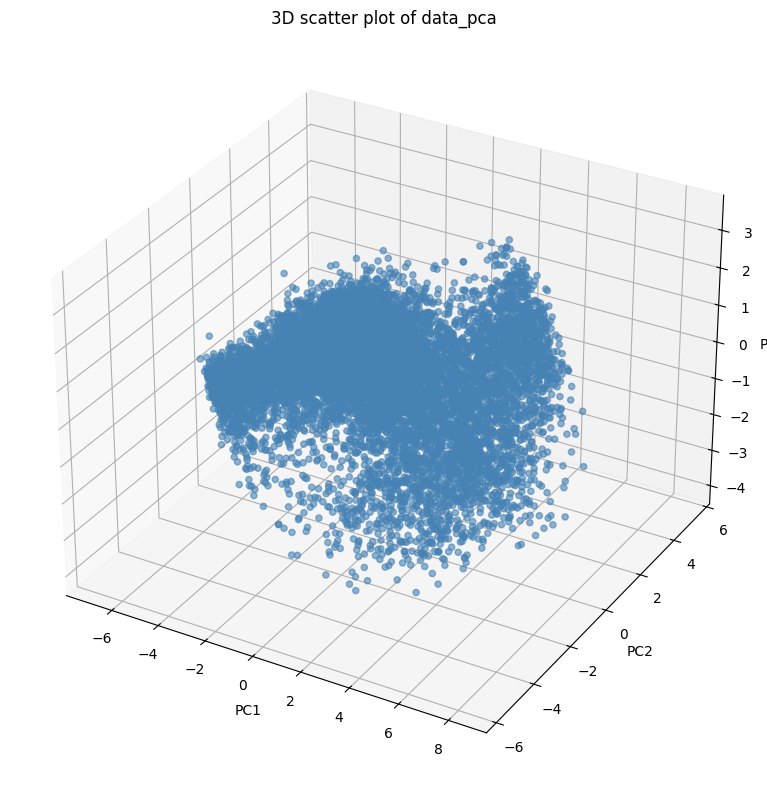

In [50]:
# Create 3D scatter plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(data_pca['PC1'], data_pca['PC2'], data_pca['PC3'],
           s=20, alpha=0.6, c='steelblue', )

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('3D scatter plot of data_pca')

plt.tight_layout()
plt.show()



- This 3D scatter plot displays the `data_pca` using its three principal components: PC1, PC2, and PC3.

- It shows the overall structure of the data in a reduced 3D space, where 89.62% of the original variance is preserved.

- Although no clear clusters are visible, the dense and complex shape suggests that clustering algorithms are needed to detect hidden patterns

# Clustering

My Choice: **K-Means**



- It was the fastest algorithm and worked efficiently with my large, high-dimensional dataset (10,594 samples, 16 features).
- Although HAC yielded slightly better Silhouette Scores, the improvement was minimal (in the range of thousandths) and did not justify the significantly higher computational cost.
- Since my dataset exhibits a globular structure, K-Means is a suitable clustering method. In such cases, the Silhouette Score is considered a reliable evaluation metric


## Comprehensive clustering analysis


**Note:** Both `data` and `data_pca` are scaled datasets. The original features were standardized using `StandardScaler` during the preprocessing step, before applying clustering in this task.


### Clustering Analysis of plain data

In [51]:
# Define consistent cluster colors 
tab10_colors = plt.colormaps.get_cmap('tab10')

cluster_palette = {
    0: tab10_colors(0),  # blue
    1: tab10_colors(1),  # orange
    2: tab10_colors(2),  # green
    3: tab10_colors(3),  # red
    4: tab10_colors(4),  # purple
    5: tab10_colors(5),  # brown
    6: tab10_colors(6),  # pink
 
}


In [52]:
# Define input data once for reproducibility and efficiency
data_kmeans = data.copy()
k_values = range(2, 12)

# Containers for evaluation scores
silhouettes = []
davies_scores = []

# Run K-Means for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_labels = kmeans.fit_predict(data_kmeans)
    
    silhouette = silhouette_score(data_kmeans, kmeans_labels)
    davies = davies_bouldin_score(data_kmeans, kmeans_labels)
    
    silhouettes.append(silhouette)
    davies_scores.append(davies)
    
    print(f"k={k} | Silhouette Score={silhouette:.3f} | Davies-Bouldin Index={davies:.3f}")


k=2 | Silhouette Score=0.421 | Davies-Bouldin Index=1.001
k=3 | Silhouette Score=0.336 | Davies-Bouldin Index=1.256
k=4 | Silhouette Score=0.268 | Davies-Bouldin Index=1.306
k=5 | Silhouette Score=0.297 | Davies-Bouldin Index=1.159
k=6 | Silhouette Score=0.288 | Davies-Bouldin Index=1.258
k=7 | Silhouette Score=0.242 | Davies-Bouldin Index=1.375
k=8 | Silhouette Score=0.234 | Davies-Bouldin Index=1.434
k=9 | Silhouette Score=0.229 | Davies-Bouldin Index=1.445
k=10 | Silhouette Score=0.226 | Davies-Bouldin Index=1.446
k=11 | Silhouette Score=0.225 | Davies-Bouldin Index=1.455


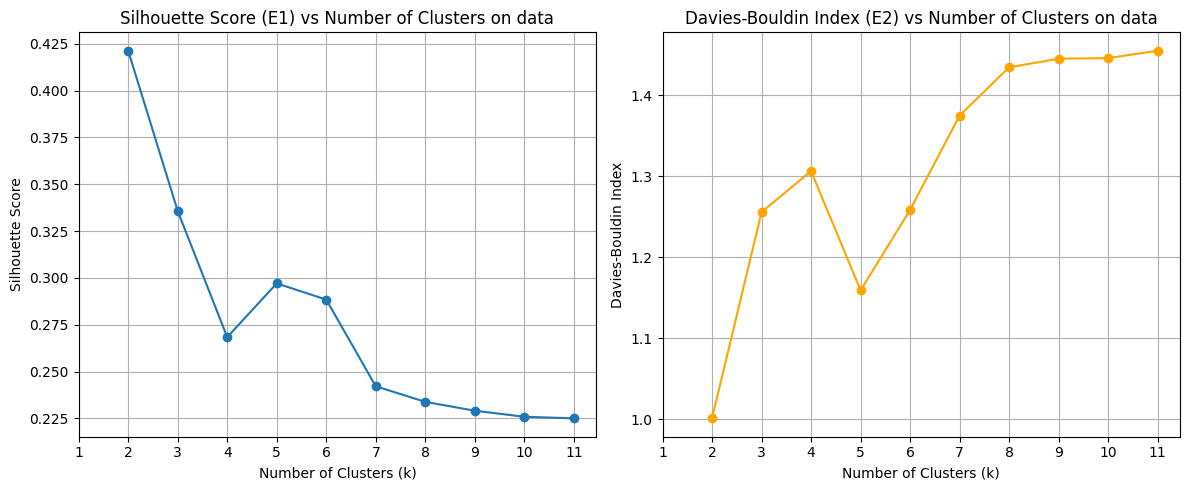

In [53]:

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, silhouettes, marker='o')
plt.title("Silhouette Score (E1) vs Number of Clusters on data")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(range(1, 12))
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(k_values, davies_scores, marker='o', color='orange')
plt.title("Davies-Bouldin Index (E2) vs Number of Clusters on data")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Davies-Bouldin Index")
plt.xticks(range(1, 12))
plt.grid(True)

plt.tight_layout()
plt.show()


* We applied K-Means to the 16D dataset `data` for k = 2 to 11.
* The best result was at **k = 2**, with a Silhouette Score of **0.421** and a Davies-Bouldin Index of **1.001**.
* Compared to other values of k, both metrics were best at k = 2, so this was selected as the final clustering for `data`.


In [54]:
# Step 1: Fit KMeans with the best number of clusters
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans_labels = kmeans.fit_predict(data_kmeans)

# Step 2: Compute Silhouette values and evaluation scores


silhouette_vals = silhouette_samples(data_kmeans, kmeans_labels)
sil_score = silhouette_score(data_kmeans, kmeans_labels)
db_score = davies_bouldin_score(data_kmeans, kmeans_labels)


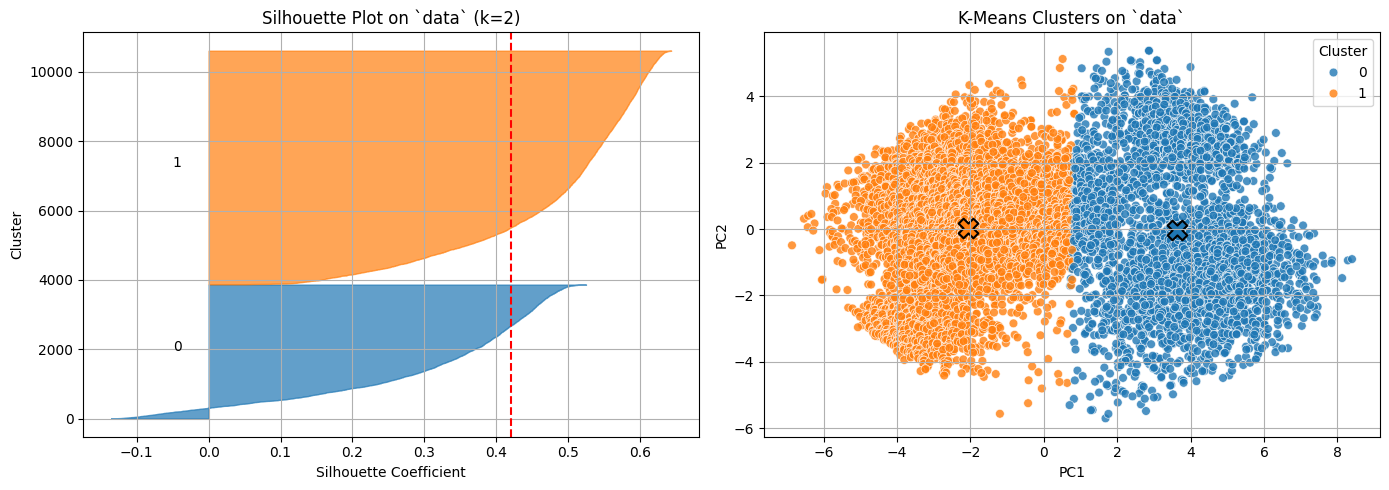

In [55]:
# PCA for visualization (data only)
pca_vis_data = PCA(n_components=2)
data_2d_kmeans_vis_data = pca_vis_data.fit_transform(data_kmeans)
centers_df_data = pd.DataFrame(kmeans.cluster_centers_, columns=data_kmeans.columns)
centers_2d_data = pca_vis_data.transform(centers_df_data)

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Plot
y_lower = 10
for i in range(k):
    ith_sil_vals = silhouette_vals[kmeans_labels == i]
    ith_sil_vals.sort()
    size_cluster_i = ith_sil_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cluster_palette[i]
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.axvline(x=sil_score, color="red", linestyle="--")
ax1.set_title(f"Silhouette Plot on `data` (k={k})")
ax1.set_xlabel("Silhouette Coefficient")
ax1.set_ylabel("Cluster")
ax1.grid(True)

# 2D PCA Scatter
sns.scatterplot(
    x=data_2d_kmeans_vis_data[:, 0], y=data_2d_kmeans_vis_data[:, 1],
    hue=kmeans_labels, palette=cluster_palette,
    s=40, alpha=0.8, edgecolor='white', ax=ax2
)

for i, center in enumerate(centers_2d_data):
    ax2.scatter(center[0], center[1], marker='X', s=200,
                c=[cluster_palette[i]], edgecolor='black', linewidth=1.5)

ax2.set_title(f"K-Means Clusters on `data`")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.legend(title='Cluster')
ax2.grid(True)

plt.tight_layout()
plt.show()


**Interpretion of k=2 Clustering on `data`**

* Cluster 0 (blue) shows lower silhouette values, including some negative values. This suggests weak internal cohesion and uncertain assignments.

* Cluster 1 (orange) has mostly higher silhouette values, indicating a better-defined and more clearly separated group.

* There is a cluster size imbalance: Cluster 1 has significantly more data points than Cluster 0.

* The average silhouette score of 0.421 and Davies-Bouldin Index of 1.001 suggest moderate clustering quality with not optimally separated clusters.

* The PCA scatter plot supports the metric results: clusters are visually distinguishable, but overlap exists at the boundary.

* Overall, the clustering quality is moderate. It reveals a basic two-group structure in the data, which may still be useful in practical applications.
 

### Clustering Analysis of PCA transformed data

In [56]:
# Step 1: Copy PCA-reduced data for reproducibility
data_pca_kmeans = data_pca.copy()

# Step 2: Range of k values to test
k_values = range(2, 11)

# Containers for evaluation metrics
inertias = []
silhouettes = []
davies_scores = []

# Step 3: Run K-Means for each k
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_labels_pca = kmeans.fit_predict(data_pca_kmeans)

    inertia = kmeans.inertia_
    silhouette = silhouette_score(data_pca_kmeans, kmeans_labels_pca)
    davies = davies_bouldin_score(data_pca_kmeans, kmeans_labels_pca)

    inertias.append(inertia)
    silhouettes.append(silhouette)
    davies_scores.append(davies)

    print(f"k={k} | Silhouette Score={silhouette:.3f} | Davies-Bouldin Index={davies:.3f}")


k=2 | Silhouette Score=0.465 | Davies-Bouldin Index=0.878
k=3 | Silhouette Score=0.309 | Davies-Bouldin Index=1.129
k=4 | Silhouette Score=0.335 | Davies-Bouldin Index=1.072
k=5 | Silhouette Score=0.367 | Davies-Bouldin Index=0.933
k=6 | Silhouette Score=0.348 | Davies-Bouldin Index=1.058
k=7 | Silhouette Score=0.345 | Davies-Bouldin Index=1.043
k=8 | Silhouette Score=0.301 | Davies-Bouldin Index=1.135
k=9 | Silhouette Score=0.298 | Davies-Bouldin Index=1.123
k=10 | Silhouette Score=0.282 | Davies-Bouldin Index=1.168


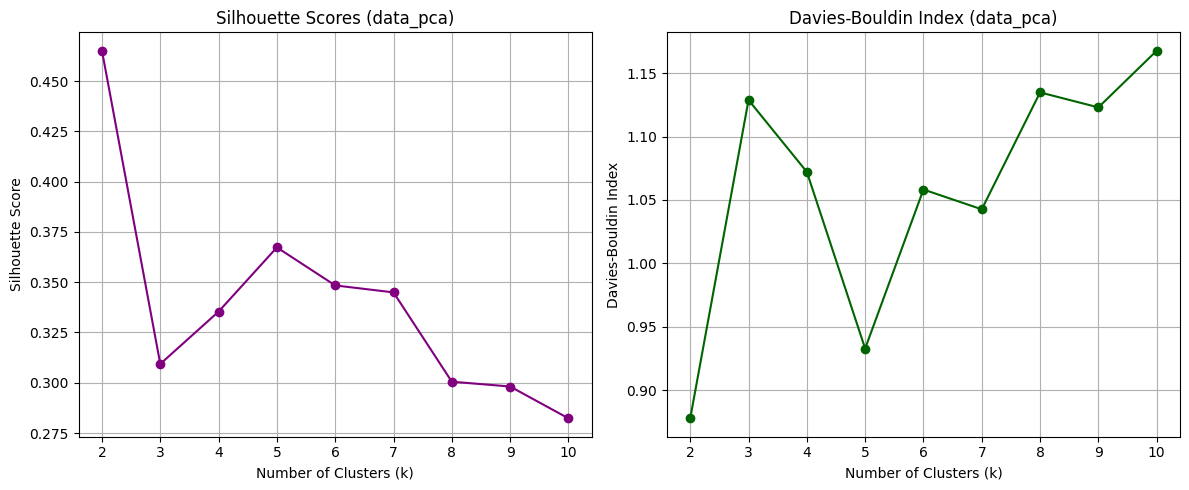

In [57]:
plt.figure(figsize=(12, 5))

# Silhouette Plot
plt.subplot(1, 2, 1)
plt.plot(k_values, silhouettes, marker='o', color='purple')
plt.title('Silhouette Scores (data_pca)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(k_values)
plt.grid(True)

# Davies-Bouldin Plot
plt.subplot(1, 2, 2)
plt.plot(k_values, davies_scores, marker='o', color='darkgreen')
plt.title('Davies-Bouldin Index (data_pca)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Davies-Bouldin Index')
plt.xticks(k_values)
plt.grid(True)

plt.tight_layout()
plt.show()


In [58]:
# Step 1: Fit KMeans on PCA data
k = 2
kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
kmeans_labels_pca = kmeans.fit_predict(data_pca_kmeans)

# Step 2: Silhouette values and final scores
silhouette_vals = silhouette_samples(data_pca_kmeans, kmeans_labels_pca)
sil_score = silhouette_score(data_pca_kmeans, kmeans_labels_pca)
db_score = davies_bouldin_score(data_pca_kmeans, kmeans_labels_pca)

print(f"Final Clustering on data_pca: k={k}")
print(f"Silhouette Score: {sil_score:.3f}")
print(f"Davies-Bouldin Index: {db_score:.3f}")


Final Clustering on data_pca: k=2
Silhouette Score: 0.465
Davies-Bouldin Index: 0.878


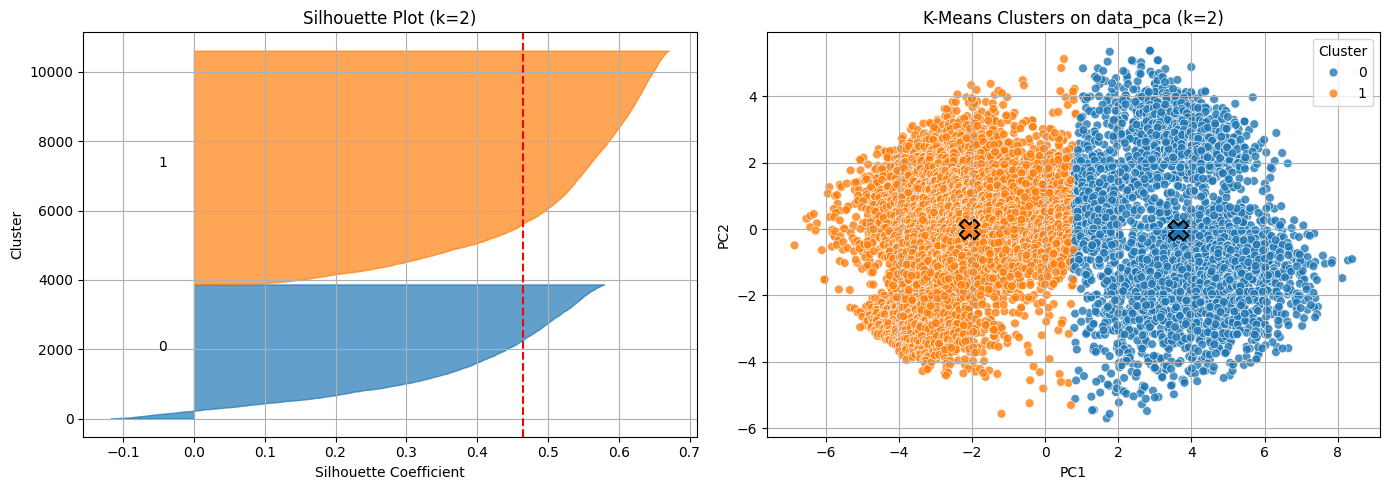

In [59]:
# Step 3: Use first two PCA components directly for 2D scatter
data_2d_kmeans_vis = data_pca_kmeans.iloc[:, [0, 1]].values
centers_df = pd.DataFrame(kmeans.cluster_centers_, columns=data_pca_kmeans.columns)
centers_2d = centers_df.iloc[:, [0, 1]].values

# Step 4: Plot silhouette and scatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Silhouette Plot
y_lower = 10
for i in range(k):
    ith_sil_vals = silhouette_vals[kmeans_labels_pca == i]
    ith_sil_vals.sort()
    size_cluster_i = ith_sil_vals.shape[0]
    y_upper = y_lower + size_cluster_i

    color = cluster_palette[i]
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_sil_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax1.axvline(x=sil_score, color="red", linestyle="--")
ax1.set_title(f"Silhouette Plot (k={k})")
ax1.set_xlabel("Silhouette Coefficient")
ax1.set_ylabel("Cluster")
ax1.grid(True)

# 2D PCA Scatter Plot
sns.scatterplot(
    x=data_2d_kmeans_vis[:, 0], y=data_2d_kmeans_vis[:, 1],
    hue=kmeans_labels_pca, palette=cluster_palette,
    s=40, alpha=0.8, edgecolor='white', ax=ax2
)

for i, center in enumerate(centers_2d):
    ax2.scatter(center[0], center[1], marker='X', s=200,
                c=[cluster_palette[i]], edgecolor='black', linewidth=1.5)

ax2.set_title(f"K-Means Clusters on data_pca (k={k})")
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.legend(title='Cluster')
ax2.grid(True)

plt.tight_layout()
plt.show()


**Interpretion of k=2 Clustering on `data_pca`**

- Cluster 0 contains some data points with negative silhouette scores, suggesting that these points may be misclassified or not well assigned to the cluster.

- Cluster 1 shows better internal structure, with silhouette scores around 0.65, which indicates good separation.

- The scatter plot supports this observation. Cluster 1 is clearly defined, while Cluster 0 is less dense this suggests that Cluster 0 is not clearly separated.

- There is also a size imbalance between the clusters. Cluster 1 has more data points, which shows that the clusters are not evenly distributed.



# Clustering Comparison

| Metric                          | data           | data_pca       |
|----------------------------------|----------------|----------------|
| Number of Clusters              | 2              | 2              |
| Silhouette Score (E1)           | 0.421          | 0.465          |
| Davies-Bouldin Index (E2)       | 1.001          | 0.878          |
| Number of Noise Points          | not applicable to K-Means |  not applicable to K-Means |


- Both clusterings used k = 2, selected based on the best performance in both evaluation metrics.

- `data_pca` slightly outperformed `data`, with a higher Silhouette Score and a lower Davies-Bouldin Index, indicating more compact and better-separated clusters.

- However, the overall improvement was modest — both the Silhouette Score and Davies-Bouldin Index still indicate only moderate cluster separation.
- The scatter plots appear visually very similar, with only a few point assignment changes between the two results. The silhouette plots also look similar in shape, showing moderate separation and compactness in both cases.


- This visual similarity may be explained by the high variance retained by PCA (89.62%) and the fact that the plots are limited to only two dimensions.

- Although the overall clustering structure remained mostly unchanged, this does not mean the clustering quality did not improve — small differences in high-dimensional space may not be visible in a 2D scatter plot, especially with over 10,000 compact data points.

- This comparison highlights the importance of using quantitative metrics, as they can reveal meaningful improvements that are not always visible in visualizations.

# Conclusions and Future Work

>


### 1. Final Clustering Selection

* The final clustering result selected for this project is the one obtained from the PCA-transformed dataset (`data_pca`) using K-Means with k = 2.

* This version showed slightly better performance than the original 16-dimensional dataset (`data`), with a higher Silhouette Score (0.465 vs. 0.421) and a lower Davies-Bouldin Index (0.878 vs. 1.001). These metrics indicate more compact and better-separated clusters.

* Although the visual differences were minimal in the scatter plots, the numerical evaluation confirmed that clustering quality improved slightly after dimensionality reduction. Therefore, the clustering on `data_pca` is chosen as the final result.


### 2. Cluster Feature Interpretation

In [60]:
data_with_final_labels = data.copy()
data_with_final_labels["Cluster"] = kmeans_labels_pca   # Note: cluster labels obtained from the data_pca K-Means model
cluster_means = data_with_final_labels.groupby("Cluster").mean().T
cluster_means


Cluster,0,1
Area,1.061656,-0.609297
Perimeter,1.109101,-0.636526
MajorAxisLength,1.143274,-0.656138
MinorAxisLength,0.830276,-0.476505
AspectRation,0.876367,-0.502958
Eccentricity,0.804840,-0.461907
ConvexArea,1.063292,-0.610236
EquivDiameter,1.063929,-0.610602
Extent,-0.180123,0.103375
Solidity,-0.522672,0.299968


 The table below shows the average standardized values of the original features for each cluster, based on the final clustering result (`data_pca`).

- **Cluster 0** has higher values in:
  - `Area` (total bean surface),
  - `Perimeter` (boundary length),
  - `MajorAxisLength` (longest diameter),
  - `AspectRatio` (length-to-width ratio),
  - `Eccentricity` (elongation level),
  
  → These suggest that Cluster 0 contains **larger, longer, and more elongated beans**.

- **Cluster 1** has higher values in:
  - `roundness` (how circular the bean is),
  - `Solidity` (compactness of shape),
  - `Compactness` (area/perimeter², compact shape measure),
  - `ShapeFactor1–4` (various shape geometry measures),
  
  → This cluster includes **more compact, rounder, and smoother beans**.


- Overall, the clustering distinguishes beans based mainly on **size and shape morphology**, which matches domain knowledge and confirms the interpretability of the result.


### 3. Summary of Achieved Results and Comparison to the Pitch

The goal outlined in the pitch was to identify distinct groups of dry beans based on their physical features. This would support automated sorting.

The final model, based on K-Means clustering on data_pca (k = 2), achieved a moderate separation of the beans:
- Silhouette Score: 0.465
- Davies-Bouldin Index: 0.878

While the results show some clustering structure, the groups are not highly distinct. This means that the goal of discovering clearly separated bean types was only partially fulfilled.

However, the clustering still revealed meaningful differences in size and shape features, which could support a basic automatic grouping system. 

Overall, the expectations from the pitch were met to a certain extent. The method worked, but the outcome indicates that dry beans may not form clearly separable clusters based on physical features alone.


### 4. Generated Value and Recommendation

* The clustering result can help the organization by grouping beans automatically. This saves time and reduces the need for manual work.

* The two clusters show differences in shape and size. This information can be useful during the sorting or packaging process. For example, beans that are longer or rounder can go into different product lines.

* Even though the clusters are not very clear, they still give useful information. The company can use this as a first step for sorting the beans. Later, the system can be improved by adding simple rules from experts or using machine learning.

**Recommendation:**  
Use this clustering to group beans early in the process. Then, combine it with domain knowledge or extra features to improve the accuracy over time.


### 5. Limitations and Possible Pitfalls

- The clustering is not perfect. The Silhouette Score (0.465) shows that the separation is only moderate.

- The algorithm group some beans incorrectly, especially when their shapes are similar.

- PCA reduces the number of features. This makes the model faster but may also remove small but important differences between beans.

- The model was trained without using the true bean types. It does not know the real categories, so it only groups beans based on physical shape and size.

- If the clustering is used without human checks, it may lead to sorting mistakes or quality issues in the product.



### 6. Future Work 

- Compare the final clustering result with the original class labels. Although labels were not used in this project, this comparison could help understand how meaningful the clusters are.

- The dataset includes 7 bean types, but the best clustering result was found at k = 2. When k = 7 was tested, the scores were much lower (Silhouette Score = 0.345, Davies-Bouldin Index = 1.043). This suggests that the current features may not be enough to fully separate all 7 types using unsupervised learning.

- Revisit the original features and check which ones contribute most to the PCA components. This may help design better physical features in future versions of the dataset.




### 7. Methodology Reflection

- The dataset included **a class column with 7 bean types.** Although this label was removed and not used in the analysis (as required by the task), **it was known from the beginning that there were 7 natural groups in the data**. However, none of the clustering algorithms were able to detect these 7 groups clearly, even at their optimal settings. This shows that unsupervised methods struggled to reflect the original class structure.

- The dataset was large (10,594 rows), and **K-Means performed much faster than DBSCAN and HAC**. In hierarchical clustering, dendrograms could only be created for small subsets, since full dendrograms were too complex to visualize. DBSCAN was also very slow and produced 3 clusters with weak separation. It also marked around 11% of the data as outliers, which reduced its usefulness.

- In fact, none of the three clustering algorithms gave their best performance at k = 7. **K-Means and HAC gave the best results with k = 2, and DBSCAN performed best with 3 clusters.** 

- **K-Means** gave the best results in terms of Silhouette Score and Davies-Bouldin Index, and produced compact, round-shaped clusters. However, the clustering **quality was still moderate**. For example, the Silhouette Score dropped from 0.465 at k = 2 to 0.345 at k = 7. This suggests that the physical features may not be enough to fully separate the beans.

- PCA was used to reduce the data from 16 dimensions to 3, while preserving 89.62% of the total variance. It helped speed up clustering and made visualization possible. However, PCA is a linear method and may not capture more complex, non-linear structures. 

- This final analysis focuses on K-Means and two internal evaluation metrics: Silhouette Score and Davies-Bouldin Index. They limited **flexibility**. Since the original labels were available, it could have been helpful to measure accuracy or clustering quality using label-based metrics. However, this was not allowed in the project.

- In future work, combining unsupervised clustering with label-based evaluation could give a more complete understanding of how well the clusters match the real bean types.


### 8. Reflection on the Results

- At the beginning of the project, my goal was to find meaningful clusters of dry beans based on their physical features. I believed that 16 features and a large number of samples would be enough to create clear and useful groupings. I also knew that the original dataset had 7 different bean types, so I hoped the clustering algorithms could find something similar without using the labels.

- I proposed using clustering to automatically group beans based on their measurements. However, based on my results, the clustering quality was only moderate. If the company uses this model in practice, some new beans could be assigned to the wrong cluster. This would reduce quality and lead to mistakes in sorting or packaging.

- Now, I think this goal was too optimistic. The clustering algorithms did not find 7 well-separated groups. In fact, the best results came from k = 2 or k = 3 with only moderate separation. The scatter plots also showed that many points were close together and not clearly grouped.

- In a future version of this project, I would also compare the clustering results with the original labels after the main unsupervised analysis. This step could help to better understand the quality and meaning of the clusters.

- In conclusion, the project was well structured, with a clear aim and good methodology, but the goal could have been more flexible and realistic.